In [3]:
import splusdata

In [41]:
bands = ["j0378", "j0395", "j0410", "j0430", "j0515", "j0660", "j0861", "g", "r", "i", "z", "u"]

In [4]:
conn = splusdata.Core()

In [5]:
tab = conn.query("""
select top 100 * from idr6.idr6           
""")

In [6]:
list(tab.columns)

['id',
 'random_idx',
 'ra',
 'dec',
 'field',
 'a_pixel_det',
 'a_restricted_pixel_r',
 'b_pixel_det',
 'b_restricted_pixel_r',
 'class_star_det',
 'class_star_g',
 'class_star_i',
 'class_star_j0378',
 'class_star_j0395',
 'class_star_j0410',
 'class_star_j0430',
 'class_star_j0515',
 'class_star_j0660',
 'class_star_j0861',
 'class_star_r',
 'class_star_u',
 'class_star_z',
 'ellipticity_det',
 'elongation_det',
 'err_a_pixel_det',
 'err_b_pixel_det',
 'err_mag_aper_3_g',
 'err_mag_aper_3_i',
 'err_mag_aper_3_j0378',
 'err_mag_aper_3_j0395',
 'err_mag_aper_3_j0410',
 'err_mag_aper_3_j0430',
 'err_mag_aper_3_j0515',
 'err_mag_aper_3_j0660',
 'err_mag_aper_3_j0861',
 'err_mag_aper_3_r',
 'err_mag_aper_3_u',
 'err_mag_aper_3_z',
 'err_mag_aper_6_g',
 'err_mag_aper_6_i',
 'err_mag_aper_6_j0378',
 'err_mag_aper_6_j0395',
 'err_mag_aper_6_j0410',
 'err_mag_aper_6_j0430',
 'err_mag_aper_6_j0515',
 'err_mag_aper_6_j0660',
 'err_mag_aper_6_j0861',
 'err_mag_aper_6_r',
 'err_mag_aper_6_u',
 '

In [7]:
hdus = conn.stamp(0.1, 0.1, 1000, "R")

In [8]:
import matplotlib.pyplot as plt
import numpy as np

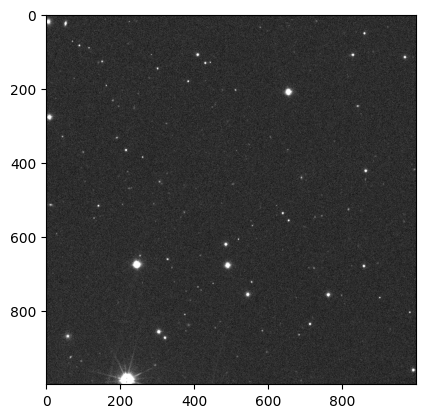

In [11]:
vmin, vmax = np.percentile(hdus[1].data, [0.1, 99.8])

plt.imshow(hdus[1].data, cmap="gray", vmin=vmin, vmax=vmax)
plt.show()

In [33]:
tab = conn.query("""select id,ra,dec from idr6.idr6 where cone(ra,dec,0.1,0.1,0.5) and mag_psf_r < 22 and err_mag_psf_r < 0.3""")

In [34]:
tab

,id,ra,dec
0,i06S82000100WMN,359.771011,-0.271295
1,i06S82000100X44,359.752388,-0.257765
2,i06S82000100WYO,359.763171,-0.264831
3,i06S82000100X1A,359.766586,-0.255552
4,i06S82000100X4C,359.772810,-0.258319
...,...,...,...
7404,i06S82000200FJ8,0.256031,0.570009
7405,i06S82000200FCX,0.272169,0.563430
7406,i06S82000200F9I,0.275467,0.559627
7407,i06S82000200FHU,0.270702,0.568445


In [35]:
# plot id ra dec over the image

from astropy.wcs import WCS

wcs = WCS(hdus[1].header)

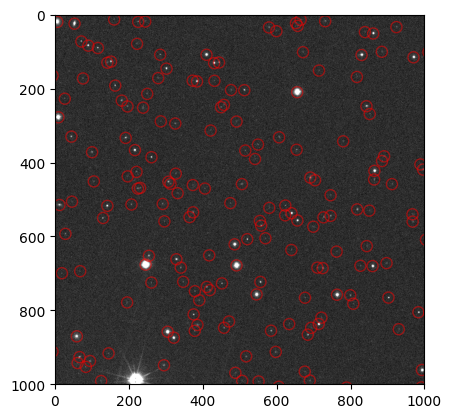

In [40]:
x, y = wcs.all_world2pix(tab['ra'], tab['dec'], 1)
plt.imshow(hdus[1].data, cmap="gray", vmin=vmin, vmax=vmax)
#plt.scatter(x, y, s=10, c='red', alpha=0.5)

# make circles around the sources
for i in range(len(x)):
    circle = plt.Circle((x[i], y[i] - 1), 15, color='red', fill=False, alpha=0.5)
    plt.gca().add_artist(circle)

# limit to the stamp size
plt.xlim(0, hdus[1].data.shape[1])
plt.ylim(hdus[1].data.shape[0], 0)

plt.show()